# Milestone 3.1 — CVD risk conversion validation

End-to-end check of `src/cvd_risk.py`: take an LDL-reduction posterior,
convert it to a **relative** CV risk reduction (RRR) via the CTT
proportional-risk relationship, then convert RRR to an **absolute** risk
reduction (ARR) given a user baseline 10-year risk.

This notebook uses a *synthetic* LDL-reduction posterior (`rng.normal`) so it
runs without MCMC — the conversion math is what we are validating, and it is
agnostic to how the LDL posterior was produced (a real `combine()` posterior
would flow through identically).

Design note: the app uses the **fixed** CTT 0.78 (`sample_effect=False`). The
effect-size CI (0.76–0.80) is a second uncertainty layer; the comparison table
below shows it widens the RRR interval by only ~1 percentage point, which is
why it is left out of the app.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent.parent))
from src.cvd_risk import cvd_rrr, cvd_arr, MG_DL_PER_MMOL, RR_PER_MMOL, RR_PER_MMOL_CI

print(f"MG_DL_PER_MMOL = {MG_DL_PER_MMOL}")
print(f"RR_PER_MMOL    = {RR_PER_MMOL}  (CI {RR_PER_MMOL_CI})")

MG_DL_PER_MMOL = 38.67
RR_PER_MMOL    = 0.78  (CI (0.76, 0.8))


## 1. One full case: LDL-reduction posterior → RRR posterior

Synthesize a final-LDL posterior centered at 90 mg/dL (from a baseline of
150 mg/dL), then push it through `cvd_rrr`. The conversion is per-sample, so
the LDL uncertainty propagates straight into the RRR posterior.

In [2]:
baseline_ldl = 150.0
rng = np.random.default_rng(1)
ldl_final = rng.normal(90.0, 8.0, 8000)   # synthetic final-LDL posterior

rrr = cvd_rrr(baseline_ldl, ldl_final)["rrr"]

def pct_ci(x):
    return x.mean() * 100, np.percentile(x, 2.5) * 100, np.percentile(x, 97.5) * 100

m, lo, hi = pct_ci(rrr)
print(f"Final LDL : mean {ldl_final.mean():.1f} mg/dL "
      f"(95% CrI {np.percentile(ldl_final,2.5):.1f}-{np.percentile(ldl_final,97.5):.1f})")
print(f"RRR       : mean {m:.1f}%  (95% CrI {lo:.1f}-{hi:.1f}%)")

Final LDL : mean 89.9 mg/dL (95% CrI 74.5-105.5)
RRR       : mean 31.9%  (95% CrI 24.9-38.4%)


## 2. RRR → ARR for a chosen baseline 10-year risk

RRR is only a multiplier; the percentage points actually avoided depend on the
user's absolute baseline risk. Take a baseline 10-year CVD risk of 20% (the
sort of number a doctor or a PCE / SCORE2 calculator would provide).

In [3]:
baseline_risk = 20.0   # percent, e.g. from PCE / SCORE2

arr_out = cvd_arr(rrr, baseline_risk)
arr, final_risk = arr_out["arr"], arr_out["final_risk"]

print(f"Baseline 10-yr risk : {baseline_risk:.1f}%")
print(f"ARR  : mean {arr.mean():.2f} pp  "
      f"(95% CrI {np.percentile(arr,2.5):.2f}-{np.percentile(arr,97.5):.2f} pp)")
print(f"Final risk : mean {final_risk.mean():.2f}%  "
      f"(95% CrI {np.percentile(final_risk,2.5):.2f}-{np.percentile(final_risk,97.5):.2f}%)")

Baseline 10-yr risk : 20.0%
ARR  : mean 6.39 pp  (95% CrI 4.98-7.69 pp)
Final risk : mean 13.61%  (95% CrI 12.31-15.02%)


## 3. Fixed vs sampled RRR — is the effect-size CI worth wiring in?

Compare the RRR interval width using the fixed CTT 0.78 against one that also
samples the per-mmol/L RR from the CTT 95% CI (0.76–0.80). If the second layer
barely moves the interval, the app is justified in leaving it out.

In [4]:
rrr_fixed   = cvd_rrr(baseline_ldl, ldl_final)["rrr"]
rrr_sampled = cvd_rrr(baseline_ldl, ldl_final, sample_effect=True, random_seed=0)["rrr"]

def width_pp(x):
    return (np.percentile(x, 97.5) - np.percentile(x, 2.5)) * 100

w_fixed, w_sampled = width_pp(rrr_fixed), width_pp(rrr_sampled)

print(f"{'variant':<10}{'mean RRR':>12}{'95% CrI width':>16}")
print(f"{'fixed':<10}{rrr_fixed.mean()*100:>11.1f}%{w_fixed:>14.2f}pp")
print(f"{'sampled':<10}{rrr_sampled.mean()*100:>11.1f}%{w_sampled:>14.2f}pp")
print(f"\nwidth ratio sampled/fixed = {w_sampled / w_fixed:.3f}x")
print("-> second layer adds ~1pp; the fixed 0.78 is a fair simplification.")

variant       mean RRR   95% CrI width
fixed            31.9%         13.56pp
sampled          31.9%         14.51pp

width ratio sampled/fixed = 1.070x
-> second layer adds ~1pp; the fixed 0.78 is a fair simplification.


## 4. Boundary checks

- Zero LDL reduction → RRR = 0 (and therefore ARR = 0).
- `0.78 ** x` is bounded in `(0, 1]` for `x >= 0`: RR can approach but never
  reach 0, so RRR stays below 100%. This is a *built-in* floor on risk —
  unlike the multiplicative LDL `combine()`, which has no biological floor and
  can drive predicted LDL implausibly low.

In [5]:
# Zero reduction -> RRR = 0 -> ARR = 0
zero = cvd_rrr(150.0, 150.0)
print(f"zero reduction: rr={zero['rr']:.3f}  rrr={zero['rrr']:.3f}")
print(f"zero reduction ARR @20%: {cvd_arr(zero['rrr'], 20.0)['arr']:.3f} pp")

# RR is bounded in (0, 1] for any reduction >= 0: even an extreme drop
# cannot push RRR to or past 100%.
extreme = cvd_rrr(300.0, 0.0)   # absurd 300 -> 0 mg/dL
print(f"\nextreme 300->0 mg/dL: rr={extreme['rr']:.4f}  rrr={extreme['rrr']:.4f}")
print(f"RRR < 1.0 (risk floored above 0): {extreme['rrr'] < 1.0}")

zero reduction: rr=1.000  rrr=0.000
zero reduction ARR @20%: 0.000 pp

extreme 300->0 mg/dL: rr=0.1455  rrr=0.8545
RRR < 1.0 (risk floored above 0): True


## 5. RRR posterior histogram

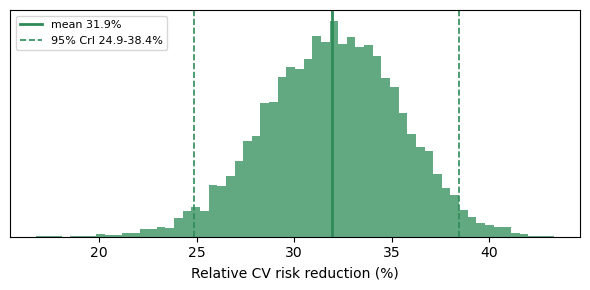

In [6]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(rrr * 100, bins=60, density=True, color="seagreen", alpha=0.75, edgecolor="none")
ax.axvline(m,  color="seagreen", lw=2, label=f"mean {m:.1f}%")
ax.axvline(lo, color="seagreen", lw=1.2, ls="--")
ax.axvline(hi, color="seagreen", lw=1.2, ls="--", label=f"95% CrI {lo:.1f}-{hi:.1f}%")
ax.set_xlabel("Relative CV risk reduction (%)")
ax.set_yticks([])
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()